
Universidade do Vale do Itajaí <br>
Escola Politécnica <br>
Processamento Digital de Sinais: Imagens <br>

### Alunos: <br>
1.      Diogo Henrique Ribicki
2.      João Victor da Silva
3.      Pedro Henrique de Paula

## Objetivo deste trabalho

Este notebook apresenta a implementação manual das operações morfológicas de **erosão** e **dilatação**, com apoio de **abertura** e **fechamento** como operações compostas.

## Ideia geral

O processamento morfológico trabalha principalmente com a forma dos objetos na imagem binária.
Nesse contexto:

- a **erosão** tende a reduzir regiões brancas;
- a **dilatação** tende a expandir regiões brancas;
- a **abertura** é uma erosão seguida de dilatação;
- o **fechamento** é uma dilatação seguida de erosão.

Ao longo do notebook, além do código, são apresentadas explicações sobre a lógica de cada função e observações sobre os efeitos visuais gerados.

## 1. Processamento Morfológico

O processamento morfológico é tratado como uma ferramenta para extrair componentes úteis da imagem, com base em conceitos de teoria dos conjuntos.
Nas operações morfológicas, utiliza-se um elemento estruturante, isto é, uma pequena máscara que percorre a imagem e decide como cada pixel será atualizado.

### Elemento estruturante

O elemento estruturante define como a vizinhança será analisada.
Em termos práticos, ele funciona como um molde.

Exemplos:
- um elemento 3x3 quadrado verifica todos os pixels vizinhos em torno do centro;
- um elemento em forma de cruz verifica principalmente vertical e horizontal;
- elementos maiores provocam efeitos mais fortes sobre a imagem.

### Operações

**Erosão:**
Mantém um pixel branco apenas quando a vizinhança exigida pelo elemento estruturante também está preenchida.
Com isso, regiões brancas encolhem, detalhes finos podem desaparecer e pequenas conexões podem ser rompidas.

**Dilatação:**
Transforma um pixel em branco quando existe correspondência suficiente com regiões brancas da imagem.
Na prática, as regiões brancas crescem, pequenos vazios podem ser reduzidos e componentes próximos podem se unir.

**Abertura:**
Suaviza contornos, remove saliências finas e tende a eliminar pequenos ruídos brancos.

**Fechamento:**
Suaviza contornos, ajuda a unir descontinuidades estreitas e pode preencher pequenos buracos.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

## 2. Funções auxiliares

Nesta etapa são criadas funções simples para:
1. ler a imagem em tons de cinza;
2. converter a imagem para binária;
3. exibir resultados;
4. criar elementos estruturantes de diferentes formatos.

A imagem binária será representada com valores:
- **0** para preto;
- **255** para branco.

In [2]:
def load_grayscale_image(image_path):
    image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Não foi possível carregar a imagem: {image_path}")

    return image

def add_padding(img, padding_height, padding_width):
    n, m = img.shape

    padded_img = np.zeros((n + padding_height * 2, m + padding_width * 2))
    padded_img[padding_height : n + padding_height, padding_width : m + padding_width] = img

    return padded_img

def to_binary(image, threshold=127):
    height, width = image.shape
    binary = np.zeros((height, width), dtype=np.uint8)

    for row in range(height):
        for col in range(width):
            if image[row, col] > threshold:
                binary[row, col] = 255
            else:
                binary[row, col] = 0

    return binary

def show_image(image, title="", cmap="gray", figsize=(6, 6)):
    plt.figure(figsize=figsize)
    plt.imshow(image, cmap=cmap)
    plt.title(title)
    plt.axis("off")
    plt.show()

def compare_images(images, titles, figsize=(16, 5), cmap="gray"):
    total = len(images)

    plt.figure(figsize=figsize)

    for index in range(total):
        plt.subplot(1, total, index + 1)
        plt.imshow(images[index], cmap=cmap)
        plt.title(titles[index])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

### 2.1 Sobre a influência do elemento estruturante

O elemento estruturante interfere diretamente no resultado final.
Quando se utiliza um elemento 3x3, o efeito tende a ser moderado. Já elementos maiores, como 5x5, produzem alterações mais intensas.

- **Square:** o elemento estruturante é preenchido totalmente com valores 1.
- **Cross:** apenas os pixels da linha central e da coluna central recebem valor 1.

Além do tamanho, a forma também altera o comportamento: um elemento quadrado tende a agir de modo mais amplo sobre a vizinhança, enquanto um elemento em cruz concentra o efeito principalmente nas direções horizontal e vertical.

In [3]:
def create_structuring_element(shape="square", size=3):
    if size % 2 == 0:
        raise ValueError("O tamanho do elemento estruturante deve ser ímpar.")

    element = np.zeros((size, size), dtype=np.uint8)
    center = size // 2

    if shape == "square":
        for row in range(size):
            for col in range(size):
                element[row, col] = 1

    elif shape == "cross":
        for row in range(size):
            element[row, center] = 1
        for col in range(size):
            element[center, col] = 1

    else:
        raise ValueError("Forma inválida. Use 'square' ou 'cross'.")

    return element

## 3. Lógica da erosão

Para cada pixel da imagem:
1. verifcamos os pixels da vizinhaça do pixel que está sendo analisado, de acordo com o tamanho do elemento estruturante;
2. se todos os pontos exigidos coincidirem com pixels brancos na imagem, o pixel de saída permanece branco;
3. caso contrário, ele se torna preto.

### Consequência visual

Essa regra faz a região branca perder pixels de borda.
Por isso, a erosão é interpretada como uma operação que contrai objetos.

In [4]:
def erode_image(binary_image, structuring_element):
    image_height, image_width = binary_image.shape
    element_height, element_width = structuring_element.shape

    padding_image = add_padding(binary_image, element_height, element_width )
    output = np.zeros((image_height, image_width), dtype=np.uint8)

    for image_row in range(image_height):
        for image_col in range(image_width):
            white = True
            for element_row in range(element_height):
                for element_col in range(element_width):
                    if (structuring_element[element_row, element_col] == 1 and
                            padding_image[element_row + image_row, element_col + image_col] == 0):
                        white = False
                        break
                if not white:
                    break

            if white:
                output[image_row, image_col] = 255
            else:
                output[image_row, image_col] = 0

    return output

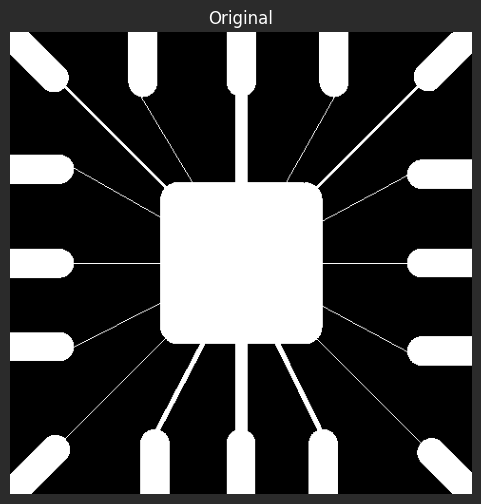

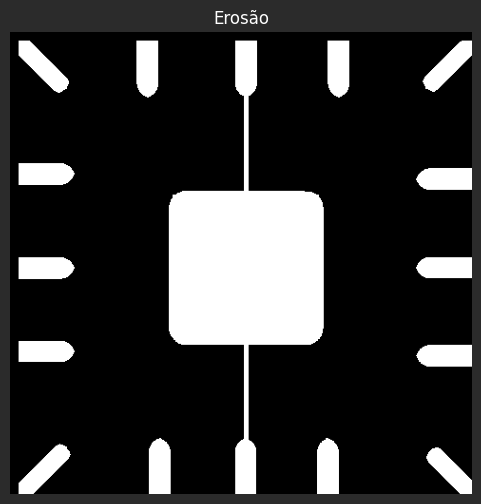

In [5]:
image_path = "data/Fig0905(a)(wirebond-mask).tif"

gray_image = load_grayscale_image(image_path)
binary_image = to_binary(gray_image, threshold=127)

structuring_element = create_structuring_element("square", 9)
eroded_image = erode_image(binary_image, structuring_element)

show_image(binary_image, "Original")
show_image(eroded_image, "Erosão")

### 3.1 Observações sobre a erosão

A erosão foi implementada por meio do percurso da imagem com um elemento estruturante.
Para cada pixel central analisado, a função verifica se todos os pontos ativos do elemento estruturante coincidem com pixels brancos da imagem binária. Quando essa condição não é satisfeita, o pixel de saída é definido como preto.
Essa lógica torna a erosão uma operação restritiva, pois apenas regiões totalmente compatíveis com o elemento estruturante permanecem na saída.

- **Comportamento nas Bordas:** Houve um afinamento visível das estruturas. As bordas externas "encolheram", reduzindo o diâmetro dos contatos circulares e das trilhas.

- **Junção:** A erosão atuou na separação de elementos que estavam muito próximos. Estruturas conectadas por apenas alguns pixels de ruído foram desconectadas.

- **Perda de Informação:** Detalhes finos e objetos menores que o elemento estruturante foram completamente eliminados. Isso é útil para remover ruídos do tipo "sal" (pontos brancos isolados).

- **Qualidade Visual:** A imagem resultante apresenta estruturas mais magras e isoladas, eliminando intrusões indesejadas, embora sacrifique a espessura original do objeto.


## 4. Lógica da dilatação

Para cada pixel da imagem:
1. analisamos a região coberta pelo elemento estruturante;
2. se existir pelo menos um encaixe válido entre um ponto ativo do elemento estruturante e um pixel branco da imagem;
3. então o pixel central da saída se torna branco.

### Consequência visual

Essa regra faz as regiões brancas crescerem.
Na prática, a dilatação expande o objeto, pode unir partes próximas e reduzir pequenos espaços.

In [6]:
def dilate_image(binary_image, structuring_element):
    image_height, image_width = binary_image.shape
    element_height, element_width = structuring_element.shape

    padding_image = add_padding(binary_image, element_height, element_width )
    output = np.zeros((image_height, image_width), dtype=np.uint8)

    for image_row in range(image_height):
        for image_col in range(image_width):
            white = False
            for element_row in range(element_height):
                for element_col in range(element_width):
                    if (structuring_element[element_row, element_col] == 1 and
                            padding_image[element_row + image_row, element_col + image_col] == 255):
                        white = True
                        break
                if white:
                    break

            if white:
                output[image_row, image_col] = 255
            else:
                output[image_row, image_col] = 0

    return output

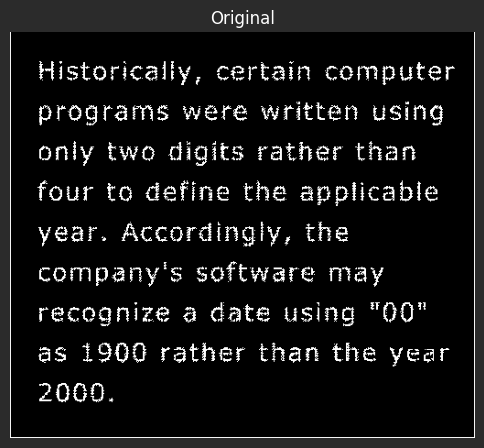

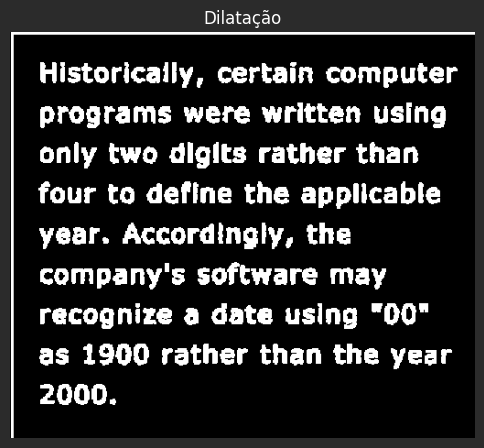

In [7]:
image_path = "data/Fig0907(a)(text_gaps_1_and_2_pixels).tif"
gray_image = load_grayscale_image(image_path)
binary_image = to_binary(gray_image, threshold=127)


structuring_element = create_structuring_element("square", 3)
dilated_image = dilate_image(binary_image, structuring_element)

show_image(gray_image, "Original")
show_image(dilated_image, "Dilatação")

### 4.1 Observações sobre a dilatação

A dilatação foi implementada utilizando o mesmo princípio de percurso da imagem, porém com uma regra menos restritiva.
Nesse caso, basta que um ponto ativo do elemento estruturante coincida com um pixel branco da imagem para que o pixel central da saída seja definido como branco.

Com isso, a dilatação expande as regiões brancas da imagem, aumenta a espessura dos objetos e pode aproximar ou unir componentes que estavam muito próximos. Também pode reduzir pequenas lacunas internas e melhorar a continuidade visual de determinadas estruturas.

- **Comportamento nas Bordas:** As bordas dos caracteres e estruturas foram expandidas para fora, aumentando a espessura geral.

- **Junção:** Este processo foi eficaz na correção de falhas. Espaços vazios de 1 ou 2 pixels dentro das letras foram preenchidos, conectando partes que deveriam ser contínuas.

- **Perda de Informação:** Houve uma perda de definição nos detalhes internos (como os "buracos" de letras como 'o' ou 'e'), que tendem a fechar se o elemento estruturante for muito grande.

- **Qualidade Visual:** Melhoria significativa na legibilidade e integridade das formas, tornando os objetos mais sólidos e contínuos.

## 5. Detecção de bordas simples com Sobel manual

1. aplicar a convolução nas direções horizontal e vertical;
2. combinar as duas respostas;
3. observar como as bordas mudam após erosão e dilatação.

In [8]:
def convolve2d(image, kernel):
    image_height, image_width = image.shape
    kernel_height, kernel_width = kernel.shape

    row_offset = kernel_height // 2
    col_offset = kernel_width // 2


    output = np.zeros((image_height, image_width), dtype=np.float32)

    for row in range(row_offset, image_height - row_offset):
        for col in range(col_offset, image_width - col_offset):
            value_sum = 0.0

            for kernel_row in range(kernel_height):
                for kernel_col in range(kernel_width):
                    image_row = row + kernel_row - row_offset
                    image_col = col + kernel_col - col_offset
                    value_sum += image[image_row, image_col] * kernel[kernel_row, kernel_col]

            output[row, col] = value_sum

    return output


def sobel_edge_detection(image):
    image_float = image.astype(np.float32)

    sobel_x = np.array([
        [-1, 0, 1],
        [-2, 0, 2],
        [-1, 0, 1]
    ], dtype=np.float32)

    sobel_y = np.array([
        [-1, -2, -1],
        [ 0,  0,  0],
        [ 1,  2,  1]
    ], dtype=np.float32)

    gradient_x = convolve2d(image_float, sobel_x)
    gradient_y = convolve2d(image_float, sobel_y)

    magnitude = np.sqrt((gradient_x ** 2) + (gradient_y ** 2))
    magnitude = np.clip(magnitude, 0, 255).astype(np.uint8)

    return magnitude

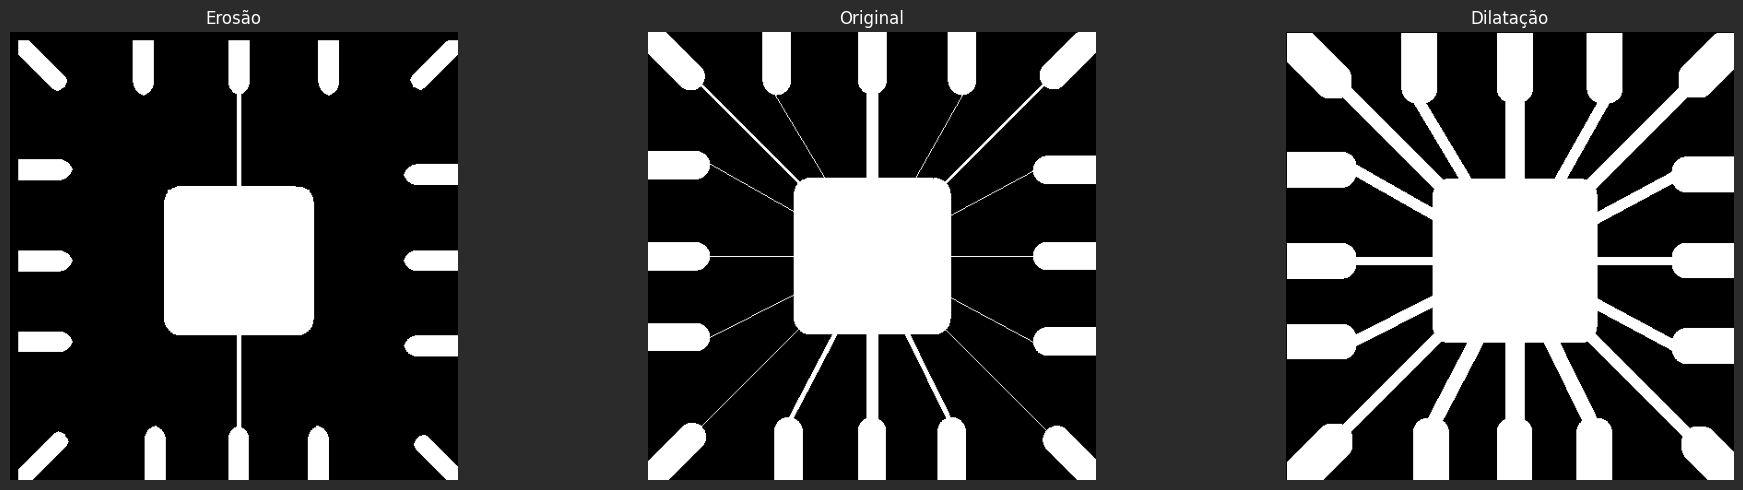

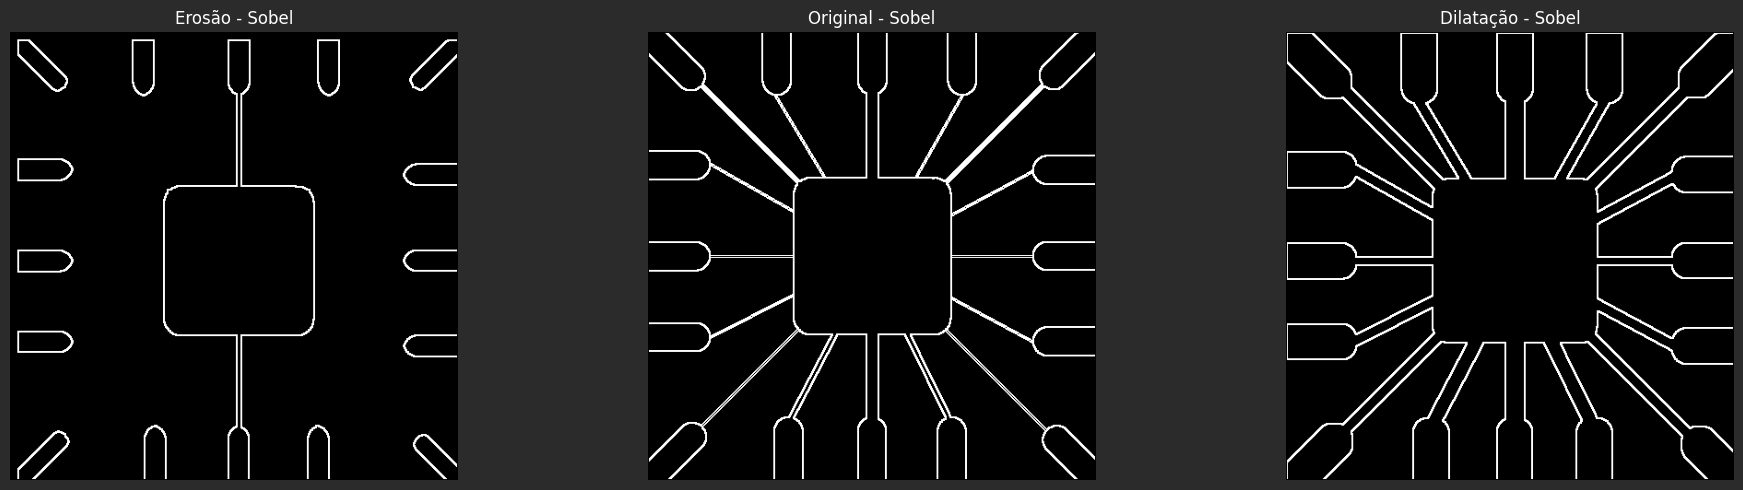

In [9]:
image_path = "data/Fig0905(a)(wirebond-mask).tif"

gray_image = load_grayscale_image(image_path)
binary_image = to_binary(gray_image, threshold=127)

structuring_element = create_structuring_element("square", 9)

image_sobel = sobel_edge_detection(binary_image)
eroded_image = erode_image(binary_image, structuring_element)
dilated_image = dilate_image(binary_image, structuring_element)

image_sobel_eroded = sobel_edge_detection(eroded_image)
image_sobel_dilated = sobel_edge_detection(dilated_image)

compare_images(
    [eroded_image, binary_image, dilated_image],
    ["Erosão", "Original", "Dilatação"],
    figsize=(20, 5)
)

compare_images(
    [image_sobel_eroded, image_sobel, image_sobel_dilated],
    ["Erosão - Sobel", "Original - Sobel", "Dilatação - Sobel"],
    figsize=(20, 5)
)

### 5.1 Comparação com detecção de bordas

A aplicação do operador de Sobel antes e depois do processamento morfológico revelou melhorias nítidas na extração de contornos. Inicialmente, a detecção de bordas na imagem original resultou em traços fragmentados e ruidosos. Contudo, após as operações de dilatação e erosão, o algoritmo gerou contornos mais definidos e contínuos, provando que a morfologia é um pré-processamento eficaz para isolar a topologia correta do objeto.

Além da qualidade visual, as bordas sofreram alterações geométricas proporcionais à operação aplicada: a erosão gerou contornos de dimensões reduzidas e sem detalhes finos, enquanto a dilatação expandiu os limites externos, evidenciando o preenchimento de lacunas e o aumento da área branca. Assim, a integração dessas técnicas permite que a morfologia prepare a imagem para uma segmentação de bordas significativamente mais precisa.

## 6. Abertura e fechamento

Essas operações são compostas pelas duas funções anteriores.

### Abertura
Abertura = erosão + dilatação

É útil para:
- remover pequenos ruídos brancos;
- quebrar conexões muito finas;
- suavizar contornos.

### Fechamento
Fechamento = dilatação + erosão

É útil para:
- preencher pequenos buracos;
- reduzir pequenas falhas no objeto;
- unir partes muito próximas.

In [10]:
def open_image(binary_image, structuring_element):
    eroded_image = erode_image(binary_image, structuring_element)
    opened_image = dilate_image(eroded_image, structuring_element)
    return opened_image


def close_image(binary_image, structuring_element):
    dilated_image = dilate_image(binary_image, structuring_element)
    closed_image = erode_image(dilated_image, structuring_element)
    return closed_image

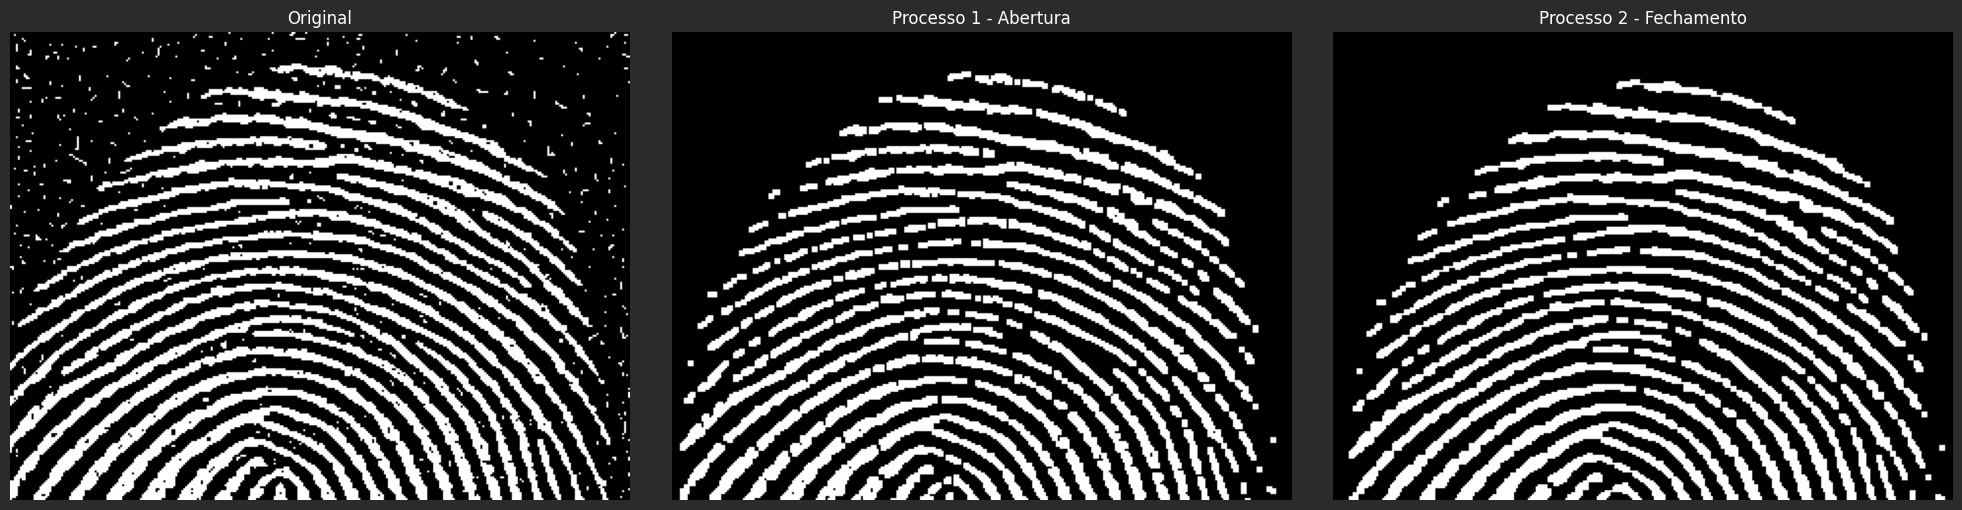

In [11]:
image_path = "data/Fig0911(a)(noisy_fingerprint).tif"
gray_image = load_grayscale_image(image_path)
binary_image = to_binary(gray_image, threshold=127)

square_3 = create_structuring_element("square", 3)


process1 = open_image(binary_image, square_3)
process2 = close_image(process1, square_3)

compare_images(
    [binary_image, process1, process2],
    ["Original", "Processo 1 - Abertura", "Processo 2 - Fechamento"],
    figsize=(20, 5)
)

### 6.1 Sobre abertura

A abertura foi aplicada como erosão seguida de dilatação. Seu principal efeito foi remover pequenas estruturas brancas e suavizar o contorno do objeto, mantendo a forma geral quando as regiões eram suficientemente grandes.

- **Comportamento:** Removeu com sucesso o ruído externo às linhas da digital (pontos brancos isolados).

- **Bordas:** Suavizou os contornos, tirando pequenas imperfeições, mas sem alterar muito o tamanho do objeto graças à dilatação que compensou isso.


### 6.2 Sobre fechamento

O fechamento foi aplicado como dilatação seguida de erosão. Seu efeito principal foi preencher pequenas falhas e reduzir descontinuidades estreitas, contribuindo para tornar a forma  mais conectada.

- **Comportamento:** Foi fundamental para unir interrupções nas linhas da impressão digital. Preencheu pequenos "buracos" pretos dentro das linhas brancas.

- **Melhoria Visual:** A combinação de ambos (Abertura para limpar e Fechamento para unir) resultou em uma imagem muito mais nítida, onde o padrão da digital tornou-se contínuo e livre de artefatos de ruído.


### 7. Conclusão

As operações morfológicas implementadas neste trabalho demonstram como a análise da vizinhança, orientada por um elemento estruturante, pode modificar a forma dos objetos em imagens binárias.
A erosão e a dilatação constituem a base desse processo, enquanto abertura e fechamento reaproveitam essas duas operações para atender objetivos mais específicos.
A integração dessas técnicas com algoritmos de detecção de bordas evidenciou que a morfologia é uma etapa de pré-processamento indispensável, garantindo a extração de contornos contínuos e condizentes com a topologia real dos objetos analisados.